# 04 - Model Comparison

This notebook implements 3 other models (in order of increasing complexity) including random forest, gradient boosting, and XGBoost and compares all subsequent results against the baseline established in `03_baseline_model`. Evaluation focuses on accuracy and per-class recall to identify the best performing model. 

**Input:** `data/processed/cleaned_data.csv`
**Output:** Model comparison table with accuracy, recall, f1-scores across the 4 models. 

In [41]:
# Setup and imports 
import pandas as pd 
import sys
sys.path.append('../')
from src.preprocessing import build_preprocessor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

ufc_data = pd.read_csv("../data/processed/cleaned_data.csv")
ufc_data.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,Winner,title_bout,weight_class,...,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds,Red_Win
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,Blue,False,Middleweight,...,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0,0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,Red,False,Women's Flyweight,...,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0,1
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,Red,False,Welterweight,...,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0,1
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,Blue,False,Featherweight,...,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0,0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,Blue,False,Middleweight,...,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0,0


In [42]:
# Split data into train and test sets

post_fight_cols = [
    'finish',              
    'finish_details',      
    'finish_round',        
    'finish_round_time',   
    'total_fight_time_secs' 
]

odds_cols = [
    'R_odds', 'B_odds', 'R_ev', 'B_ev',
    'r_dec_odds', 'b_dec_odds',
    'r_sub_odds', 'b_sub_odds',
    'r_ko_odds', 'b_ko_odds'
]

id_cols = ['R_fighter', 'B_fighter', 'date', 'Winner']
cols_to_remove = post_fight_cols + odds_cols + id_cols 

X = ufc_data.drop(columns=['Red_Win', 'Winner', 'date', 'R_fighter', 'B_fighter'] + cols_to_remove)
y = ufc_data['Red_Win']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

### Random Forest

An ensemble model that builds multiple decision trees in parallel, each trained on a random subset of data and features. Predictions are made by majority vote across all trees, reducing overfitting compared to a single decision tree.

In [43]:
# Create Random Forest model 
preprocessor = build_preprocessor(numeric_cols, categorical_cols)

# Chain into pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)


### Evaluation

Accuracy: 0.614
              precision    recall  f1-score   support

           0       0.55      0.37      0.44       598
           1       0.64      0.79      0.70       838

    accuracy                           0.61      1436
   macro avg       0.60      0.58      0.57      1436
weighted avg       0.60      0.61      0.60      1436



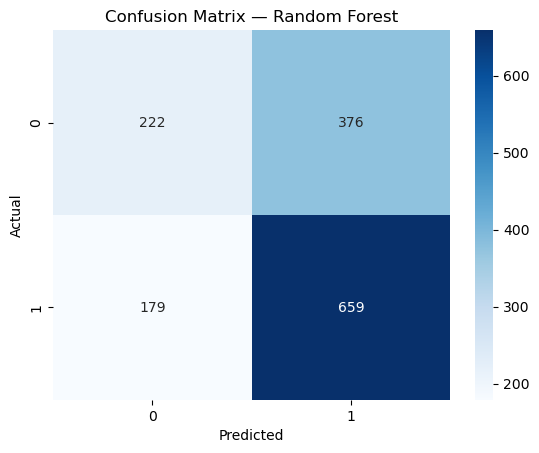

In [44]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Random Forest')
plt.show()

### Random Forest Results 
- **Accuracy:** 0.614 — this is below the logistic regression baseline of 0.634
- **Class 0 Recall:** 0.37 — this is significantly worse than baseline (0.52), model is heavily biased toward predicting Red wins
- **Note:** Default Random Forest underperforms the baseline, likely due to class imbalance and untuned hyperparameters. Hyperparameter tuning in notebook 05 may recover performance.

### Gradient Boosting

Builds trees sequentially where each tree focuses on correcting the errors of the previous one. Unlike Random Forest which builds trees in parallel, boosting iteratively reduces bias by learning from its own mistakes, typically producing stronger predictions at the cost of longer training time.

In [45]:
# Implement Gradient Boost Model 

pipeline_gbr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

pipeline_gbr.fit(X_train, y_train)
y_pred_gbr = pipeline_gbr.predict(X_test)


### Evaluation

Accuracy: 0.608
              precision    recall  f1-score   support

           0       0.55      0.34      0.42       598
           1       0.63      0.80      0.70       838

    accuracy                           0.61      1436
   macro avg       0.59      0.57      0.56      1436
weighted avg       0.60      0.61      0.59      1436



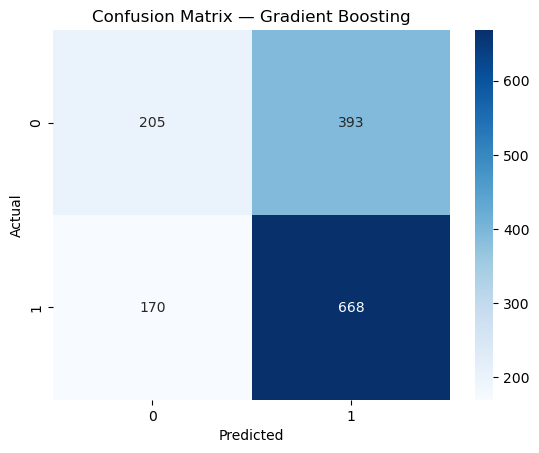

In [46]:
# Evaluate performance 

print(f"Accuracy: {accuracy_score(y_test, y_pred_gbr):.3f}")
print(classification_report(y_test, y_pred_gbr))

cm = confusion_matrix(y_test, y_pred_gbr)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Gradient Boosting')
plt.show()

### Gradient Boosting Results 
- **Accuracy:** 0.608 — this is below the logistic regression baseline of 0.634
- **Class 0 Recall:** 0.34 — this is significantly worse than baseline (0.52), model is heavily biased toward predicting Red wins
- **Note:** Default Gradient Boosting also underperforms the baseline, likely due to class imbalance and untuned hyperparameters. Hyperparameter tuning in notebook 05 may recover performance.

### XGBoost 

An optimized implementation of gradient boosting with built-in regularization (L1/L2), faster training through parallelization, and native missing value handling. 

In [47]:
# Implement XGBoost

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

### Evaluation

Accuracy: 0.596
              precision    recall  f1-score   support

           0       0.52      0.43      0.47       598
           1       0.64      0.71      0.67       838

    accuracy                           0.60      1436
   macro avg       0.58      0.57      0.57      1436
weighted avg       0.59      0.60      0.59      1436



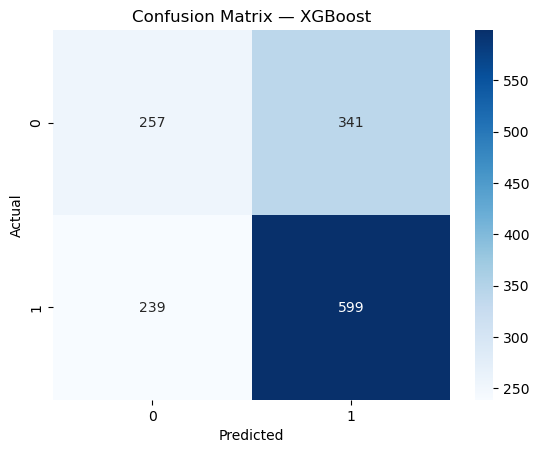

In [48]:
# Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — XGBoost')
plt.show()

### XGBoost Results
- **Accuracy:** 0.596 — this is below the logistic regression baseline of 0.634
- **Class 0 Recall:** 0.43 — this is higher than the other 2 models, model is still biased toward predicting Red wins
- **Note:** Default XGBoost underperforms the baseline, likely due to class imbalance and untuned hyperparameters. Hyperparameter tuning in notebook 05 may also recover performance.

## Model Comparison Summary

| Model | Accuracy | Class 0 Recall | Class 1 Recall | F1 (macro) |
|-------|----------|----------------|----------------|------------|
| Logistic Regression (baseline) | 0.634 | 0.41 | 0.79 | 0.60 |
| Random Forest | 0.614 | 0.37 | 0.79 | 0.57 |
| Gradient Boosting | 0.608 | 0.34 | 0.80 | 0.56 |
| XGBoost | 0.596 | 0.43 | 0.71 | 0.57 |

**Selected model for tuning:** XGBoost — While logistic regression achieved the highest raw accuracy (0.634), XGBoost is selected for hyperparameter tuning in `05_hyperparameter_tuning.ipynb` due to its superior class balance — highest class 0 recall (0.43) across all models — and its greater capacity for improvement through tuning (learning rate, max depth, subsample, regularization).